## Análisis de features

In [1]:
import json
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

records = []
for f in Path("../features_damian").glob("*/*/features.json"):
    d = json.load(f.open())
    fijaciones = d.pop("fijaciones")
    for fix in fijaciones:
        records.append({**d, **fix})

df = pd.DataFrame(records)

In [45]:
# ── Grupos por categoría semántica ──────────────────────────────────────────

FEATURES_BOTTOM_UP = [
    "saliencia_media",
    "saliencia_mediana",
    "saliencia_pixel",
]

FEATURES_SIMILITUD_TARGET = [
    "similitud_media",
    "similitud_mediana",
    "similitud_pixel",
]

FEATURES_ESTADO_BAYESIANO = [
    "evidencia_visual",
    "competencia_fp_var",
    "competencia_fp_media",
    "competencia_fp_max",
    "posterior",
    "entropia_prior_saliencia",
    #"entropia_prior_modelo",
    "entropia_posterior",
    "ganancia_informacion",
]

FEATURES_CALIDAD_DECISION = [
    #"eig_optimo",
    #"eig_en_fijacion",
    "gap_entropia",
    "distancia_grilla",
    "distancia_pixels",
]

FEATURES_COMPETENCIA_CANDIDATOS = [
    #"competencia_ratio_mayor",
    #"competencia_ratio_segundo_mayor",
    "competencia_ratio",
    "competencia_densidad",
    "competencia_densidad_norm",
]

## BLOQUE 1 — Validación Computacional

**Objetivo**: para cada trial (imagen × sujeto), verificar que la cantidad de mapas generados por el modelo coincide con la cantidad de fijaciones humanas.

Un desajuste implica que hay fijaciones sin mapa asociado (o mapas extra), lo que rompe el mapping 1-a-1 necesario para extraer features por fijación.

In [46]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

HUMAN_SP_DIR = Path("../hybrid_metadata/human_scanpaths")
MAPS_DIR     = Path("../hybrid_metadata/Results/maps/HSUBANOTT")

MAP_KEYS = ["visual_evidence", "posterior", "entropy_map", "expected_ig_map"]

records = []

for sp_file in sorted(HUMAN_SP_DIR.glob("*_scanpaths.json")):
    subject_id = sp_file.stem.replace("_scanpaths", "")
    human_sp   = json.loads(sp_file.read_text())

    for trial_idx, (image_name, trial) in enumerate(human_sp.items()):
        npz_path = MAPS_DIR / subject_id / image_name.replace(".jpg", ".npz")

        if npz_path.exists():
            npz    = np.load(npz_path, allow_pickle=True)
            counts = {k: int(npz[k].shape[0]) for k in MAP_KEYS}
        else:
            counts = {k: None for k in MAP_KEYS}

        records.append({
            "imagen":       image_name,
            "sujeto":       subject_id,
            "trial":        trial_idx,
            "n_fijaciones": len(trial["X"]),
            **counts,
        })

diag = pd.DataFrame(records)
diag


,imagen,sujeto,trial,n_fijaciones,visual_evidence,posterior,entropy_map,expected_ig_map
0,cmp_building_056_bird_012.jpg,117969,0,15,14.0,14.0,14.0,14.0
1,cmp_shelves_101_teddybear_014.jpg,117969,1,22,21.0,21.0,21.0,21.0
2,cmp_yard_003_animal_002.jpg,117969,2,6,5.0,5.0,5.0,5.0
3,cmp_snow_004_dog_001.jpg,117969,3,19,18.0,18.0,18.0,18.0
4,cmp_shelves_109_teddybear_022.jpg,117969,4,16,15.0,15.0,15.0,15.0
...,...,...,...,...,...,...,...,...
4538,cmp_shelves_111_pottedplant_002.jpg,S119,93,6,5.0,5.0,5.0,5.0
4539,cmp_building_039_dog_007.jpg,S119,94,35,34.0,34.0,34.0,34.0
4540,cmp_office_001_pottedplant_001.jpg,S119,95,17,16.0,16.0,16.0,16.0
4541,cmp_yard_001_birds_001.jpg,S119,96,19,18.0,18.0,18.0,18.0


In [47]:
diag["n_mapas"] = diag[MAP_KEYS[0]]

diag["diff"] = diag["n_fijaciones"] - diag["n_mapas"]

print("Distribución de diferencias (n_fijaciones - n_mapas):")
print(diag["diff"].value_counts().sort_index().to_string())

print(f"\nTrials con diff != 1 : {(diag['diff'] != 1).sum()}")
print(f"Trials con diff == 1 : {(diag['diff'] == 1).sum()}  ({100*(diag['diff']==1).mean():.1f}%)")

print("""
--- Causa estructural ---
El loop en visual_searcher.py corre fixation_number de 0 a max_saccades (= N-1).
En la última iteración (fixation_number == max_saccades) hace break ANTES de llamar
on_fixation_computed → la última fijación humana nunca genera mapa.

Consecuencia: el mapa i corresponde a la fijación humana i (0-indexed),
y la fijación N-1 (la última) queda sin mapa asociado.
""")

print("Trials con outliers (diff != 1) — revisar manualmente:")
display(diag[diag["diff"] != 1].reset_index(drop=True))


Distribución de diferencias (n_fijaciones - n_mapas):
diff
1.0    4501

Trials con diff != 1 : 42
Trials con diff == 1 : 4501  (99.1%)

--- Causa estructural ---
El loop en visual_searcher.py corre fixation_number de 0 a max_saccades (= N-1).
En la última iteración (fixation_number == max_saccades) hace break ANTES de llamar
on_fixation_computed → la última fijación humana nunca genera mapa.

Consecuencia: el mapa i corresponde a la fijación humana i (0-indexed),
y la fijación N-1 (la última) queda sin mapa asociado.

Trials con outliers (diff != 1) — revisar manualmente:


,imagen,sujeto,trial,n_fijaciones,visual_evidence,posterior,entropy_map,expected_ig_map,n_mapas,diff
0,cmp_shelves_103_teddybear_016.jpg,117969,27,1,NaN,NaN,NaN,NaN,NaN,NaN
1,cmp_shelves_096_teddybear_009.jpg,117969,71,1,NaN,NaN,NaN,NaN,NaN,NaN
2,cmp_beach_002_person_002.jpg,159640,68,1,NaN,NaN,NaN,NaN,NaN,NaN
3,cmp_shelves_036_book_009.jpg,159640,81,1,NaN,NaN,NaN,NaN,NaN,NaN
4,cmp_beach_003_bird_001.jpg,179678,25,1,NaN,NaN,NaN,NaN,NaN,NaN
5,cmp_shelves_096_teddybear_009.jpg,244108,27,1,NaN,NaN,NaN,NaN,NaN,NaN
6,cmp_shelves_112_pottedplant_003.jpg,244108,90,1,NaN,NaN,NaN,NaN,NaN,NaN
7,cmp_shelves_103_teddybear_016.jpg,244389,65,1,NaN,NaN,NaN,NaN,NaN,NaN
8,cmp_building_014_person_007.jpg,286470,67,1,NaN,NaN,NaN,NaN,NaN,NaN
9,cmp_shelves_103_teddybear_016.jpg,286470,70,1,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# Ejemplo concreto: primer trial del primer sujeto con mapa disponible
row      = diag[diag["visual_evidence"].notna()].iloc[0]
subject  = row["sujeto"]
image    = row["imagen"]

sp_file  = HUMAN_SP_DIR / f"{subject}_scanpaths.json"
trial    = json.loads(sp_file.read_text())[image]
npz      = np.load(MAPS_DIR / subject / image.replace(".jpg", ".npz"), allow_pickle=True)

fix_x = trial["X"]
fix_y = trial["Y"]
n_fix = len(fix_x)
n_map = int(npz["visual_evidence"].shape[0])

print(f"Sujeto : {subject}")
print(f"Imagen : {image}")
print(f"Fijaciones humanas : {n_fix}")
print(f"Mapas en NPZ       : {n_map}")
print()
print(f"{'Fix #':<6} {'X':>8} {'Y':>8}   {'Mapa?'}")
print("-" * 35)
for i, (x, y) in enumerate(zip(fix_x, fix_y)):
    tiene_mapa = "✓" if i < n_map else "✗  ← SIN MAPA (última fijación)"
    print(f"  {i:<4} {x:>8.1f} {y:>8.1f}   {tiene_mapa}")


Sujeto : 117969
Imagen : cmp_building_056_bird_012.jpg
Fijaciones humanas : 15
Mapas en NPZ       : 14

Fix #         X        Y   Mapa?
-----------------------------------
  0       367.3    434.2   ✓
  1       206.7    396.4   ✓
  2       383.5    224.8   ✓
  3       656.9    336.1   ✓
  4       948.1    215.8   ✓
  5       797.3     63.5   ✓
  6       757.6     77.4   ✓
  7       128.0    115.4   ✓
  8        98.5    893.6   ✓
  9       310.9    868.3   ✓
  10      274.5    878.1   ✓
  11      565.4    925.1   ✓
  12      992.8    900.2   ✓
  13      945.7    911.4   ✓
  14     1103.2    409.6   ✗  ← SIN MAPA (última fijación)


In [49]:
diag['diff'] = diag['n_fijaciones'] - diag['n_mapas']
diag['diff'].describe()

count    4501.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: diff, dtype: float64

## BLOQUE 2 — Estadísticas Descriptivas por Feature

Objetivo: demostrar que las features están bien calculadas antes de analizarlas

#### Maximo, minimo, media

In [50]:
df[['saliencia_media', 'saliencia_mediana', 'saliencia_pixel','similitud_media', 'similitud_mediana', 'similitud_pixel']].describe()

,saliencia_media,saliencia_mediana,saliencia_pixel,similitud_media,similitud_mediana,similitud_pixel
count,61252.000000,61252.000000,61252.000000,61252.000000,61252.000000,61252.000000
mean,0.104571,0.100437,0.044859,0.090995,0.083541,0.033391
std,0.140770,0.139108,0.095360,0.117171,0.115706,0.071481
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.016422,0.015686,0.000000,0.013319,0.011765,0.003922
50%,0.050735,0.047059,0.007843,0.045150,0.037255,0.007843
75%,0.130879,0.125490,0.043137,0.125096,0.109804,0.031373
max,0.900969,0.905882,1.000000,0.826765,0.835294,0.949020


In [51]:
df[['evidencia_visual', 'competencia_fp_var', 'competencia_fp_media','competencia_fp_max']].describe()

,evidencia_visual,competencia_fp_var,competencia_fp_media,competencia_fp_max
count,61252.000000,61252.000000,61252.000000,6.125200e+04
mean,-3.358863,4.603246,-0.195339,4.832762e+00
std,2.281987,1.578183,0.083481,1.030737e+01
min,-8.906335,0.231135,-0.341853,5.775774e-19
25%,-4.688323,3.495107,-0.242732,3.065932e-02
50%,-3.755527,4.497744,-0.216957,4.842565e-01
75%,-2.711403,5.587414,-0.182885,3.529978e+00
max,8.437602,13.584946,0.298265,7.420025e+01


In [52]:
df[['posterior','entropia_prior_saliencia','entropia_prior_modelo','entropia_posterior']].describe()

,posterior,entropia_prior_saliencia,entropia_prior_modelo,entropia_posterior
count,6.125200e+04,61252.000000,61252.000000,61252.000000
mean,1.518335e-02,5.449638,5.735732,5.347059
std,9.389148e-02,0.447305,0.520445,1.714386
min,4.439850e-20,3.848590,1.591179,0.000014
25%,5.062587e-06,5.283264,5.606650,5.366429
50%,2.299719e-05,5.482193,5.844613,6.099882
75%,9.799675e-05,5.788606,6.048017,6.375862
max,9.999551e-01,6.152672,6.323267,6.583734


In [53]:
df[['ganancia_informacion','eig_optimo','eig_en_fijacion','gap_entropia']].describe()

,ganancia_informacion,eig_optimo,eig_en_fijacion,gap_entropia
count,56751.000000,61252.000000,5.675100e+04,56751.000000
mean,0.213994,0.962514,1.856385e-01,0.711167
std,0.455556,1.197410,5.171009e-01,1.036964
min,0.000003,0.071553,2.126091e-09,0.000000
25%,0.025735,0.218277,2.889746e-02,0.126588
50%,0.051715,0.382540,5.956947e-02,0.262108
75%,0.142838,1.082344,1.012579e-01,0.702412
max,5.900233,4.483477,4.477109e+00,4.483477


In [54]:
df[['distancia_grilla','competencia_ratio_mayor','competencia_ratio_segundo_mayor','competencia_ratio','competencia_densidad','competencia_densidad_norm']].describe()

,distancia_grilla,competencia_ratio_mayor,competencia_ratio_segundo_mayor,competencia_ratio,competencia_densidad,competencia_densidad_norm
count,56751.000000,61252.000000,61252.000000,61252.000000,61252.000000,61252.000000
mean,9.914661,0.962514,0.866638,0.926711,1.787893,0.002328
std,6.034990,1.197410,1.062298,0.056161,1.816932,0.002366
min,0.000000,0.071553,0.071346,0.763010,1.000000,0.001302
25%,5.385165,0.218277,0.206646,0.888762,1.000000,0.001302
50%,9.433981,0.382540,0.355936,0.939605,1.000000,0.001302
75%,13.928388,1.082344,0.966588,0.973550,2.000000,0.002604
max,31.764760,4.483477,4.151845,0.999998,96.000000,0.125000


## BLOQUE 3 — Análisis distribucional

**Objetivo**: caracterizar la distribución de cada feature e identificar cuáles son degeneradas.

**Nota temporal**: algunas features son **estáticas por trial** (se computan una vez por imagen, mismo valor en todas las fijaciones del trial):
- `entropia_prior_saliencia`, `entropia_prior_modelo` → prior inicial, no cambia tras la primera fijación

El resto son **dinámicas por fijación** (el posterior se actualiza con cada fijación).

**Criterios de descarte por degeneración**:
- Varianza ≈ 0 (std < 1e-4)
- Punto-masa: >30% de valores idénticos (modo exacto)
- Cola pesada: >5% de outliers extremos (Tukey k=3, fuera de Q1−3·IQR / Q3+3·IQR)
- Cobertura: >10% NaN

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

FEAT_GROUPS = {
    'Bottom-Up':     FEATURES_BOTTOM_UP,
    'Similitud':     FEATURES_SIMILITUD_TARGET,
    'Est.Bayesiano': FEATURES_ESTADO_BAYESIANO,
    'Cal.Decisión':  FEATURES_CALIDAD_DECISION,
    'Competencia':   FEATURES_COMPETENCIA_CANDIDATOS,
}

LOG_FEATS = {'ganancia_informacion', 'eig_en_fijacion', 'distancia_pixels',
             'competencia_fp_max', 'posterior'}

GROUP_COLORS = {
    'Bottom-Up':     '#2196F3',
    'Similitud':     '#4CAF50',
    'Est.Bayesiano': '#FF9800',
    'Cal.Decisión':  '#E91E63',
    'Competencia':   '#9C27B0',
}

ALL_FEATS     = [f for feats in FEAT_GROUPS.values() for f in feats]
FEAT_TO_GROUP = {f: g for g, feats in FEAT_GROUPS.items() for f in feats}

print(f"Features totales: {len(ALL_FEATS)} | en df: {sum(f in df.columns for f in ALL_FEATS)}")

Features totales: 20 | en df: 20


In [56]:
def outlier_pct(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return 100 * ((s < q1 - k * iqr) | (s > q3 + k * iqr)).mean()

def mode_pct(s):
    """% del valor más frecuente exacto (proxy punto-masa para features discretizadas)."""
    return 100 * s.value_counts(normalize=True).iloc[0]

rows = []
for feat in ALL_FEATS:
    s = df[feat].dropna() if feat in df.columns else pd.Series(dtype=float)
    q1 = s.quantile(0.25) if len(s) else np.nan
    q3 = s.quantile(0.75) if len(s) else np.nan
    rows.append({
        'group':        FEAT_TO_GROUP[feat],
        'n':            len(s),
        'pct_nan':      round(100 * (1 - len(s) / len(df)), 1) if feat in df.columns else 100.0,
        'mean':         s.mean(),
        'median':       s.median(),
        'std':          s.std(),
        'iqr':          q3 - q1,
        'min':          s.min(),
        'max':          s.max(),
        'pct_outliers': round(outlier_pct(s), 2) if len(s) else np.nan,
        'pct_mode':     round(mode_pct(s), 1) if len(s) else np.nan,
    })

stats_df = pd.DataFrame(rows, index=pd.Index(ALL_FEATS, name='feature'))

display(
    stats_df.style
    .format({'mean': '{:.4f}', 'median': '{:.4f}', 'std': '{:.4f}', 'iqr': '{:.4f}',
             'min': '{:.2e}', 'max': '{:.4f}', 'n': '{:,.0f}',
             'pct_nan': '{:.1f}%', 'pct_outliers': '{:.2f}%', 'pct_mode': '{:.1f}%'})
    .background_gradient(subset=['pct_outliers'], cmap='YlOrRd')
    .background_gradient(subset=['pct_mode'],     cmap='YlOrRd')
    .background_gradient(subset=['pct_nan'],      cmap='Blues')
)

,group,n,pct_nan,mean,median,std,iqr,min,max,pct_outliers,pct_mode
feature,,,,,,,,,,,
saliencia_media,Bottom-Up,"61,252",0.0%,0.1046,0.0507,0.1408,0.1145,0.00e+00,0.9010,3.58%,3.6%
saliencia_mediana,Bottom-Up,"61,252",0.0%,0.1004,0.0471,0.1391,0.1098,0.00e+00,0.9059,3.68%,7.1%
saliencia_pixel,Bottom-Up,"61,252",0.0%,0.0449,0.0078,0.0954,0.0431,0.00e+00,1.0000,6.97%,37.7%
similitud_media,Similitud,"61,252",0.0%,0.0910,0.0451,0.1172,0.1118,0.00e+00,0.8268,2.14%,1.2%
similitud_mediana,Similitud,"61,252",0.0%,0.0835,0.0373,0.1157,0.0980,0.00e+00,0.8353,3.10%,9.6%
similitud_pixel,Similitud,"61,252",0.0%,0.0334,0.0078,0.0715,0.0275,0.00e+00,0.9490,7.33%,24.0%
evidencia_visual,Est.Bayesiano,"61,252",0.0%,-3.3589,-3.7555,2.2820,1.9769,-8.91e+00,8.4376,3.82%,0.0%
competencia_fp_var,Est.Bayesiano,"61,252",0.0%,4.6032,4.4977,1.5782,2.0923,2.31e-01,13.5849,0.03%,0.0%
competencia_fp_media,Est.Bayesiano,"61,252",0.0%,-0.1953,-0.2170,0.0835,0.0598,-3.42e-01,0.2983,5.62%,0.0%


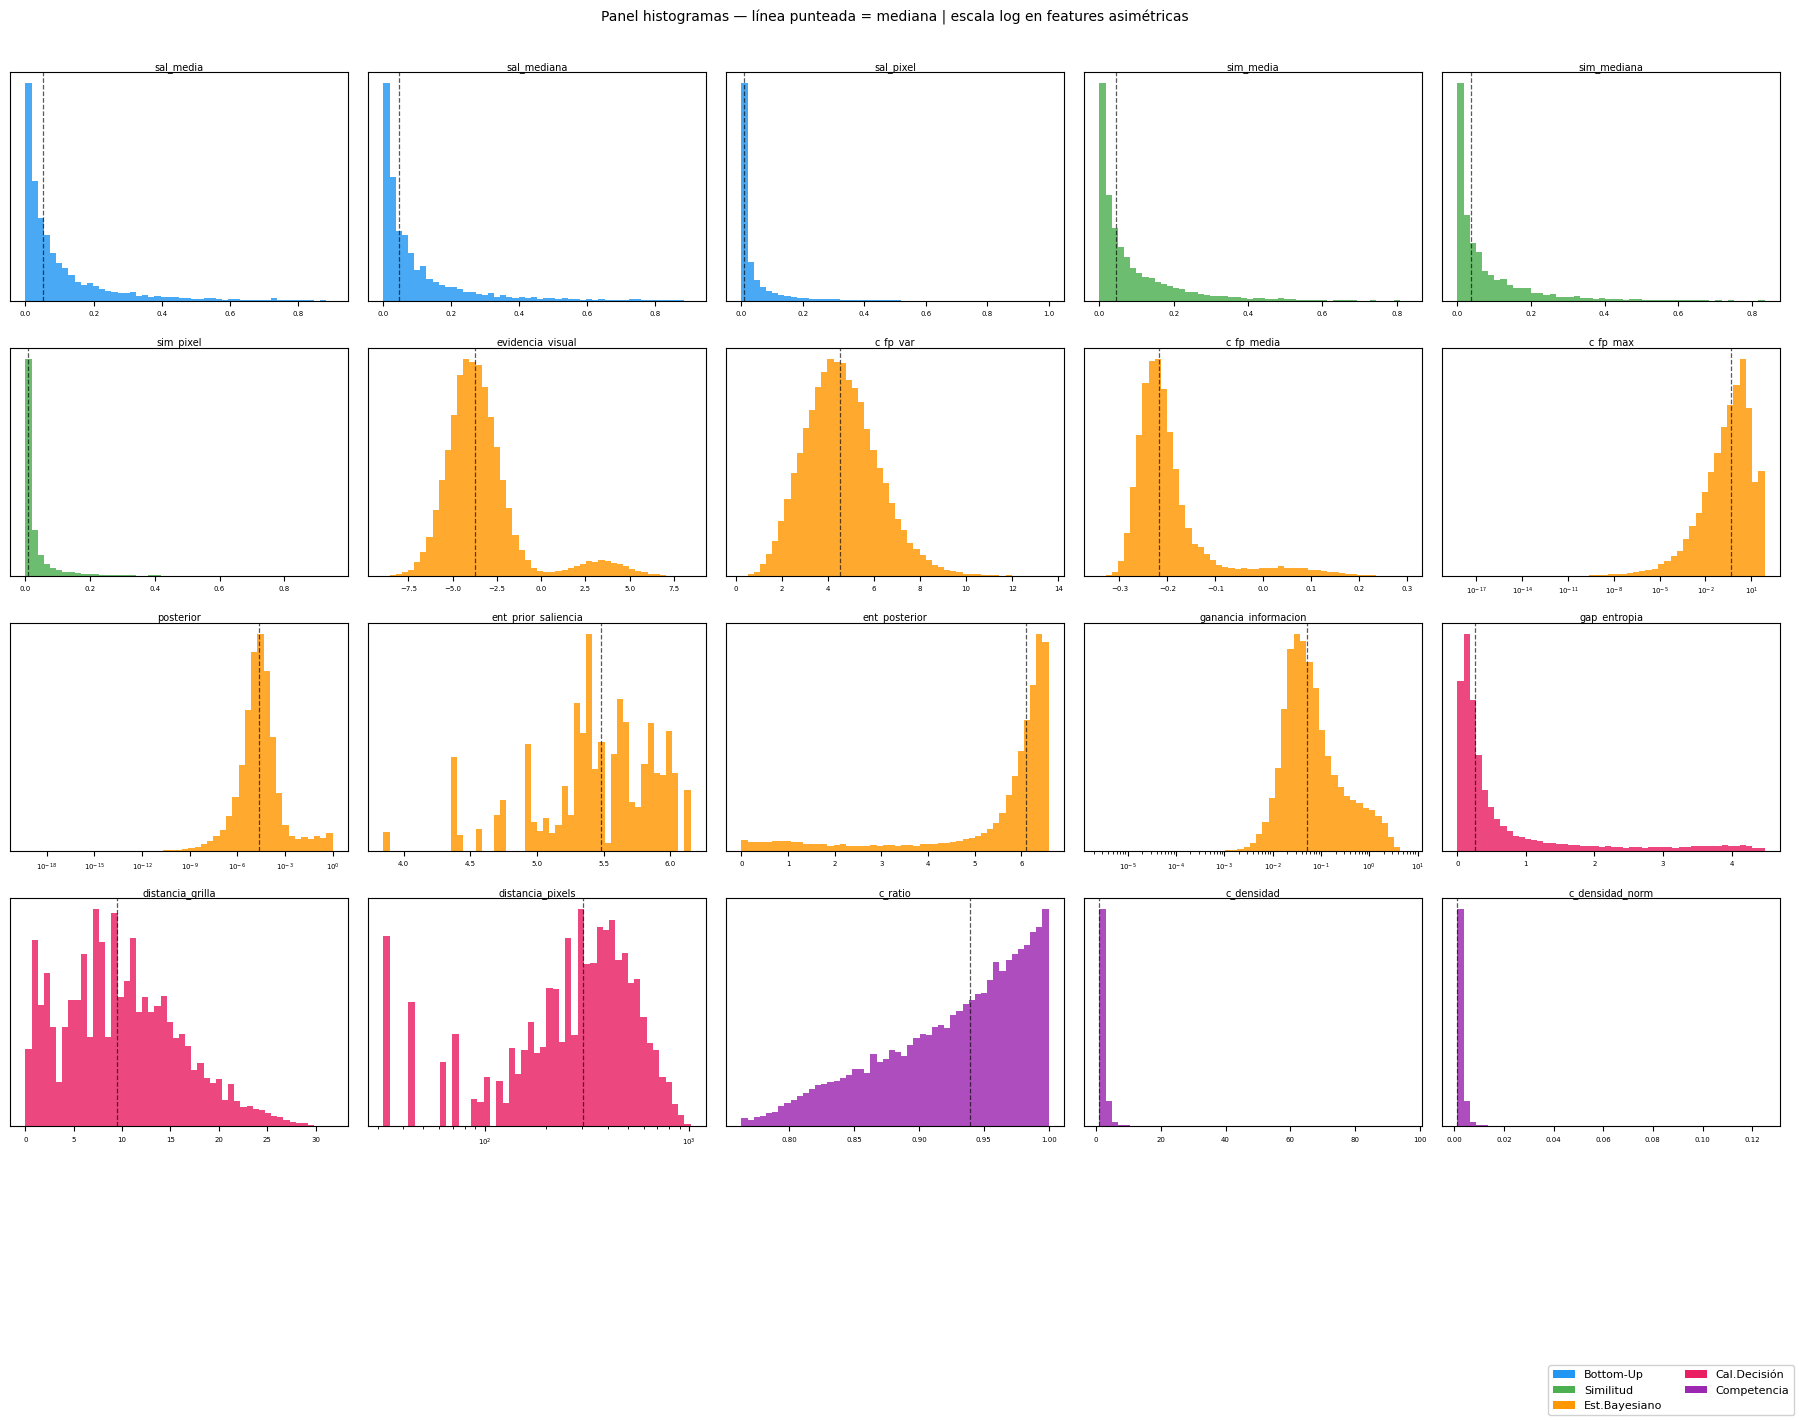

In [57]:
fig, axes = plt.subplots(5, 5, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(ALL_FEATS):
    ax = axes[i]
    s = df[feat].dropna() if feat in df.columns else pd.Series(dtype=float)
    color    = GROUP_COLORS[FEAT_TO_GROUP[feat]]
    use_log  = feat in LOG_FEATS

    if use_log:
        vals = s[s > 0]
        bins = np.geomspace(vals.min(), vals.max(), 50) if len(vals) > 1 else 50
    else:
        vals, bins = s, 50

    ax.hist(vals, bins=bins, color=color, alpha=0.82, edgecolor='none')
    if use_log:
        ax.set_xscale('log')
    ax.axvline(vals.median(), color='k', lw=0.9, ls='--', alpha=0.65)

    short = (feat.replace('competencia_', 'c_')
                 .replace('entropia_',    'ent_')
                 .replace('saliencia_',   'sal_')
                 .replace('similitud_',   'sim_'))
    ax.set_title(short, fontsize=7, pad=2)
    ax.tick_params(labelsize=5)
    ax.set_yticks([])

for j in range(len(ALL_FEATS), len(axes)):
    axes[j].set_visible(False)

legend_handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=legend_handles, loc='lower right', ncol=2, fontsize=8, framealpha=0.9)
plt.suptitle('Panel histogramas — línea punteada = mediana | escala log en features asimétricas',
             fontsize=10, y=1.005)
plt.tight_layout()
plt.savefig('bloque2_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

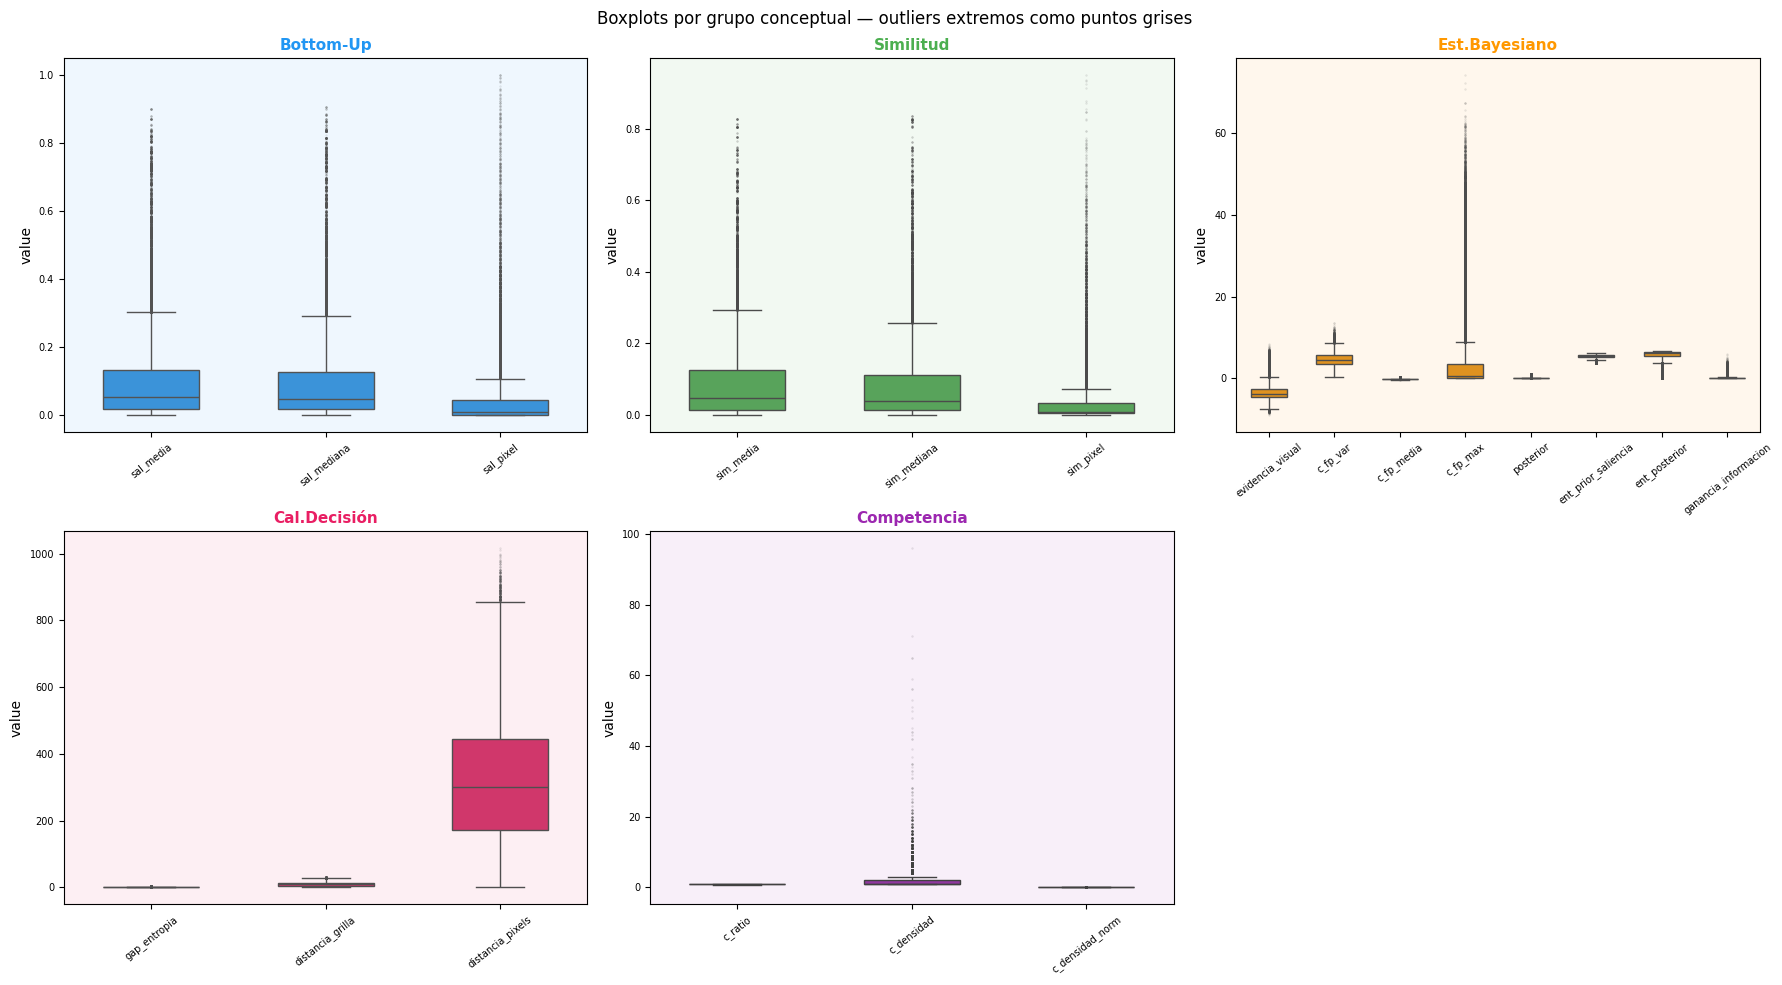

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

SHORT = lambda f: (f.replace('competencia_', 'c_')
                    .replace('entropia_',    'ent_')
                    .replace('saliencia_',   'sal_')
                    .replace('similitud_',   'sim_'))

for i, (group, feats) in enumerate(FEAT_GROUPS.items()):
    ax = axes[i]
    feats_ok = [f for f in feats if f in df.columns]

    melted = (df[feats_ok]
              .rename(columns={f: SHORT(f) for f in feats_ok})
              .melt(var_name='feature', value_name='value'))

    sns.boxplot(
        data=melted, x='feature', y='value', ax=ax,
        color=GROUP_COLORS[group],
        flierprops=dict(marker='.', markersize=1.2, alpha=0.15, color='gray'),
        width=0.55,
    )
    ax.set_facecolor(GROUP_COLORS[group] + '12')
    ax.set_title(group, fontsize=11, fontweight='bold', color=GROUP_COLORS[group])
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=38, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

axes[-1].set_visible(False)

plt.suptitle('Boxplots por grupo conceptual — outliers extremos como puntos grises', fontsize=12)
plt.tight_layout()
plt.savefig('bloque2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
THRESH_POINTMASS = 30.0   # % moda > 30 → punto-masa
THRESH_OUTLIERS  =  5.0   # % outliers Tukey-k3 > 5 → cola pesada
THRESH_NAN       = 10.0   # % NaN > 10 → cobertura incompleta

flagged, ok_feats = [], []

for feat in ALL_FEATS:
    row   = stats_df.loc[feat]
    flags = []
    if row['std'] < 1e-4:
        flags.append(f'varianza~0 (std={row["std"]:.2e})')
    if row['pct_mode'] > THRESH_POINTMASS:
        flags.append(f'punto-masa ({row["pct_mode"]:.1f}% en moda)')
    if row['pct_outliers'] > THRESH_OUTLIERS:
        flags.append(f'outliers extremos ({row["pct_outliers"]:.1f}%)')
    if row['pct_nan'] > THRESH_NAN:
        flags.append(f'NaN alto ({row["pct_nan"]:.1f}%)')

    if flags:
        flagged.append({'feature': feat, 'group': row['group'], 'flags': flags})
    else:
        ok_feats.append(feat)

sep = '=' * 68
print(f'{sep}')
print(f'Features candidatas a descarte/revision: {len(flagged)} de {len(ALL_FEATS)}')
print(f'{sep}')
for item in flagged:
    print(f'\n  [{item["group"]:10s}] {item["feature"]}')
    for flag in item['flags']:
        print(f'               -> {flag}')

print(f'\n{sep}')
print(f'Features sin flags ({len(ok_feats)}):')
for f in ok_feats:
    print(f'  [ok] {f}')

Features candidatas a descarte/revision: 10 de 20

  [Bottom-Up ] saliencia_pixel
               -> punto-masa (37.7% en moda)
               -> outliers extremos (7.0%)

  [Similitud ] similitud_pixel
               -> outliers extremos (7.3%)

  [Est.Bayesiano] competencia_fp_media
               -> outliers extremos (5.6%)

  [Est.Bayesiano] competencia_fp_max
               -> outliers extremos (10.7%)

  [Est.Bayesiano] posterior
               -> outliers extremos (12.4%)

  [Est.Bayesiano] entropia_posterior
               -> outliers extremos (10.9%)

  [Est.Bayesiano] ganancia_informacion
               -> outliers extremos (11.4%)

  [Cal.Decisión] gap_entropia
               -> outliers extremos (9.7%)

  [Competencia] competencia_densidad
               -> punto-masa (56.7% en moda)

  [Competencia] competencia_densidad_norm
               -> punto-masa (56.7% en moda)

Features sin flags (10):
  [ok] saliencia_media
  [ok] saliencia_mediana
  [ok] similitud_media
  [ok] si

## BLOQUE 4 — Coherencia temporal con el proceso bayesiano

**Objetivo**: verificar que las features evolucionan a lo largo del trial de forma consistente con la dinámica esperada del modelo.

| Feature | Comportamiento esperado | Signo Spearman(rank, feature) |
|---------|------------------------|-------------------------------|
| `entropia_posterior` | Decrece — el modelo gana certeza | − |
| `ganancia_informacion` | Alta al inicio, decrece al converger | − |
| `posterior` | Aumenta en la celda del target | + |
| `gap_entropia` | Debería reducirse junto a la entropía | − |
| `eig_optimo` / `eig_en_fijacion` | Decrece al converger | − |
| `similitud_media/pixel` | Aumenta si el sujeto se acerca al target | + |
| `competencia_ratio` | Sin dirección clara a priori | ~ |

**Análisis estadístico**: Spearman(rank, feature) computado por sujeto (pooling sus trials), luego testeado contra H₀: r=0 con Wilcoxon + corrección Bonferroni.

In [60]:
from scipy.stats import spearmanr, wilcoxon, ttest_1samp

# rank 1-indexed para display / MSS desde memory_set
df['rank'] = df['fixation'] + 1
df['mss']  = df['memory_set'].apply(len)

# Hipótesis direccionales: signo esperado de Spearman(rank, feature)
DIRECTIONAL = {
    'entropia_posterior':   -1,
    'ganancia_informacion': -1,
    'posterior':            +1,
    'gap_entropia':         -1,
    'eig_optimo':           -1,
    'eig_en_fijacion':      -1,
    'similitud_media':      +1,
    'similitud_pixel':      +1,
    'competencia_ratio':     0,
    'distancia_grilla':      0,
    'distancia_pixels':      0,
}

KEY_FEATS = [
    'entropia_posterior', 'ganancia_informacion', 'posterior', 'gap_entropia',
    'similitud_media',    'competencia_ratio',    'eig_optimo', 'eig_en_fijacion',
]

MAX_RANK = 12   # la mayoría de trials terminan antes de rank 12

# Display config (usada en múltiples celdas de este bloque)
color_map = {True: '#1565C0', False: '#C62828'}
label_map = {True: 'target encontrado', False: 'target no encontrado'}
dir_label = {-1: 'esperado: decrece', +1: 'esperado: aumenta', 0: 'sin dir. esperada'}

print(f"rank range  : {df['rank'].min()}–{df['rank'].max()}")
print(f"MSS values  : {sorted(df['mss'].unique())}")
print(f"target_found: {df['target_found'].value_counts().to_dict()}")
print(f"N fijaciones con rank <= {MAX_RANK}: {(df['rank'] <= MAX_RANK).sum():,}")

rank range  : 1–46
MSS values  : [1, 2, 4]
target_found: {True: 33018, False: 28234}
N fijaciones con rank <= 12: 40,994


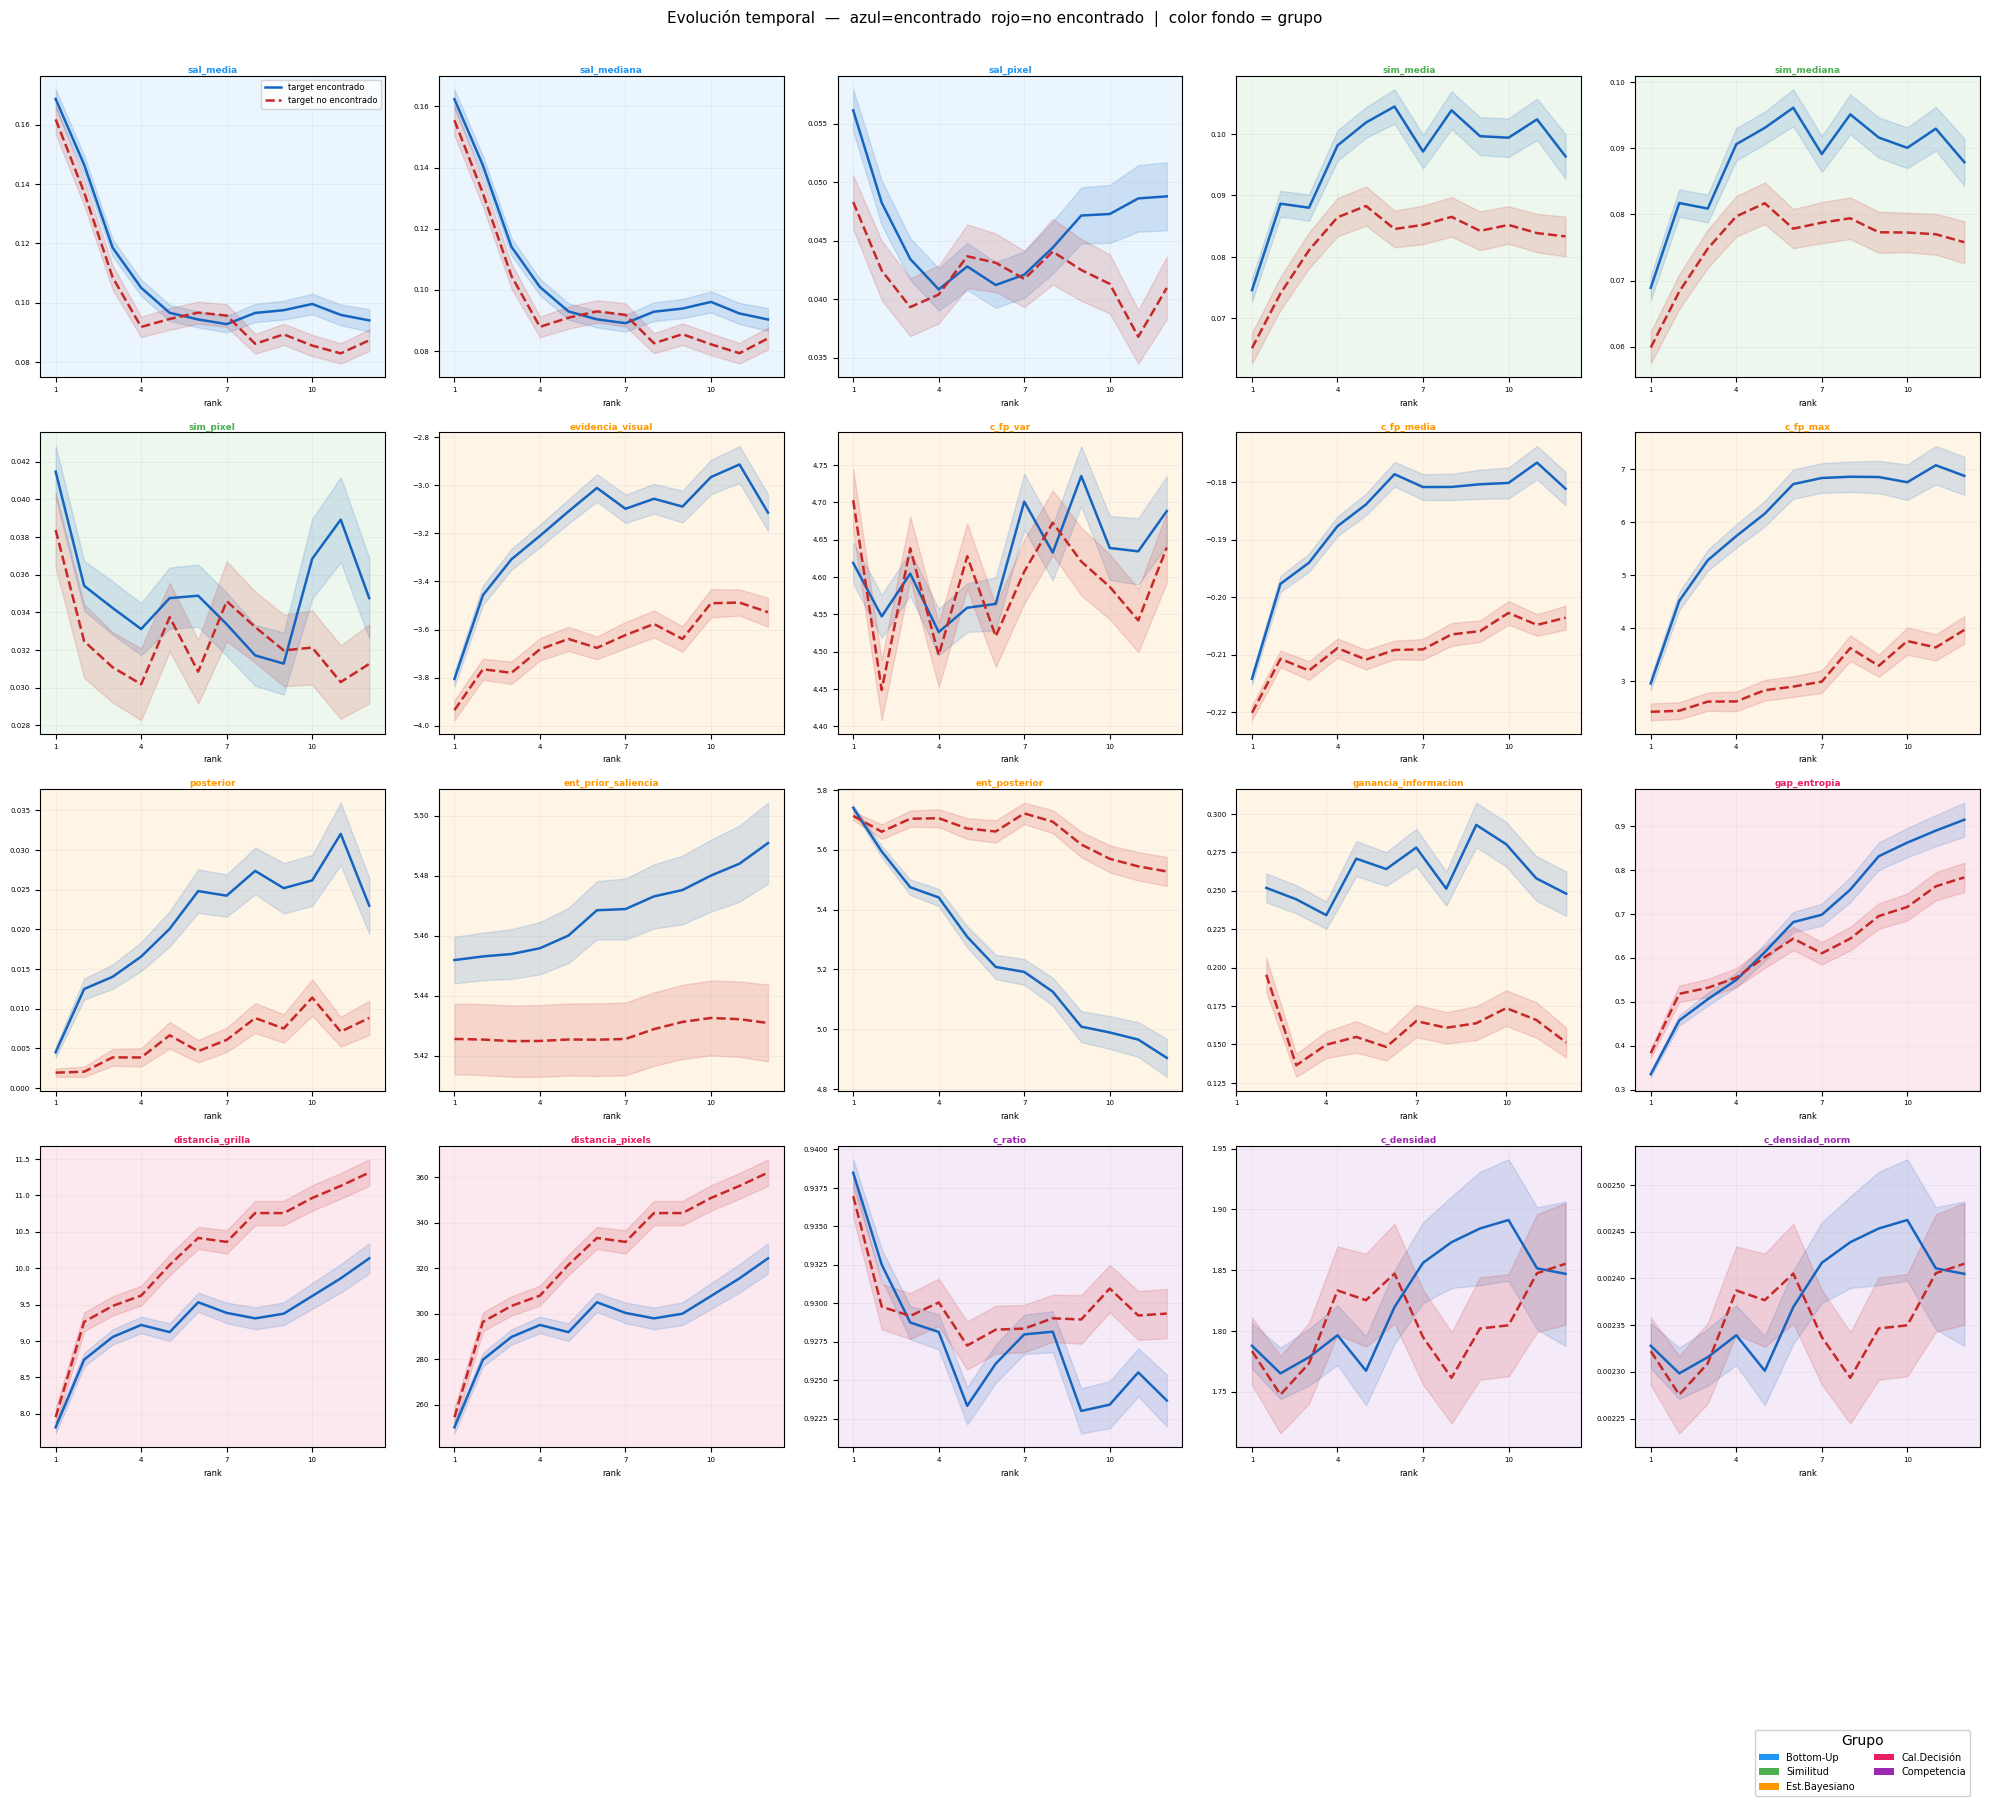

In [61]:
fig, axes = plt.subplots(5, 5, figsize=(20, 18), sharey=False)
axes = axes.flatten()

subset_rank = df[df['rank'] <= MAX_RANK]

for ax, feat in zip(axes, ALL_FEATS):
    color = GROUP_COLORS[FEAT_TO_GROUP[feat]]
    ax.set_facecolor(color + '18')

    for found in [True, False]:
        grp     = subset_rank[subset_rank['target_found'] == found]
        by_rank = grp.groupby('rank')[feat]
        means   = by_rank.mean()
        sems    = by_rank.sem()
        x = means.index
        ls = '-' if found else '--'
        ax.plot(x, means, color=color_map[found], label=label_map[found], lw=1.8, ls=ls)
        ax.fill_between(x, means - sems, means + sems,
                        color=color_map[found], alpha=0.15)

    short = (feat.replace('competencia_', 'c_')
                 .replace('entropia_',    'ent_')
                 .replace('saliencia_',   'sal_')
                 .replace('similitud_',   'sim_'))
    ax.set_title(short, fontsize=6.5, pad=2, color=color, fontweight='bold')
    ax.set_xlabel('rank', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_xticks(range(1, MAX_RANK + 1, 3))
    ax.grid(True, alpha=0.25, lw=0.4)

for j in range(len(ALL_FEATS), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=6, loc='best')

legend_group = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=legend_group, loc='lower right', ncol=2, fontsize=7,
           bbox_to_anchor=(0.99, 0.01), framealpha=0.9, title='Grupo')

plt.suptitle('Evolución temporal  —  azul=encontrado  rojo=no encontrado  |  color fondo = grupo',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.savefig('bloque3_curvas_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

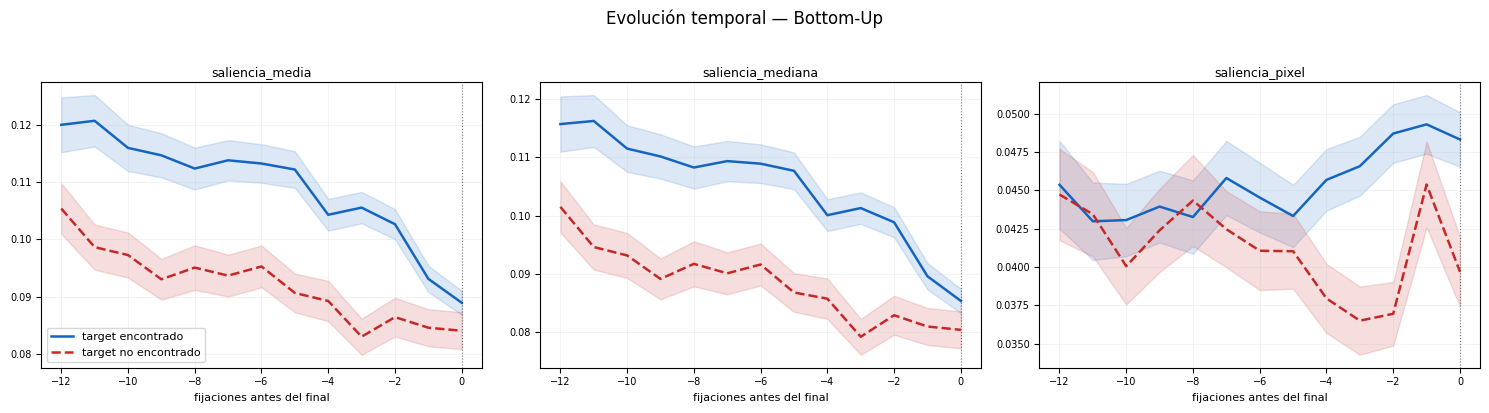

Guardado: curvas_backward_bottom-up.png


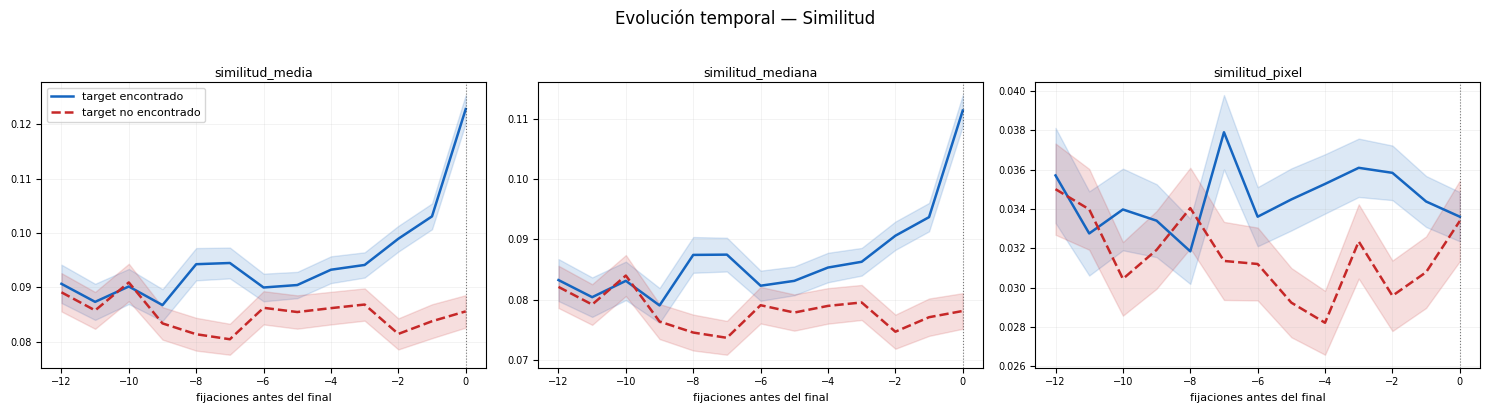

Guardado: curvas_backward_similitud.png


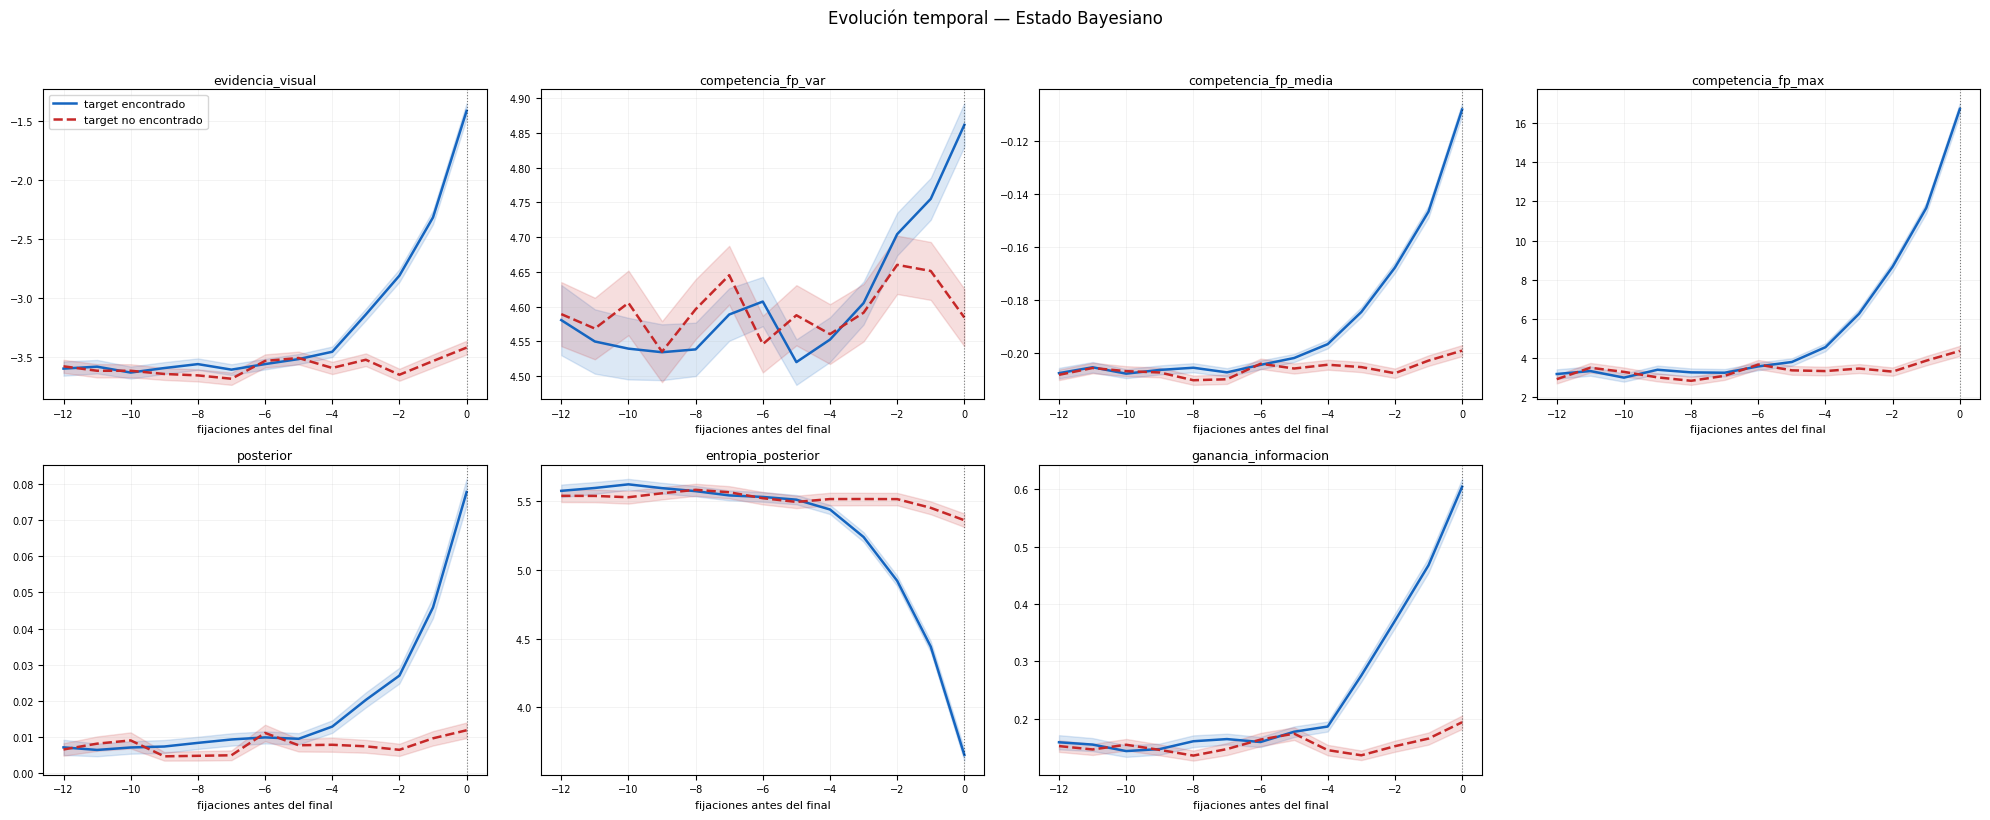

Guardado: curvas_backward_estado_bayesiano.png


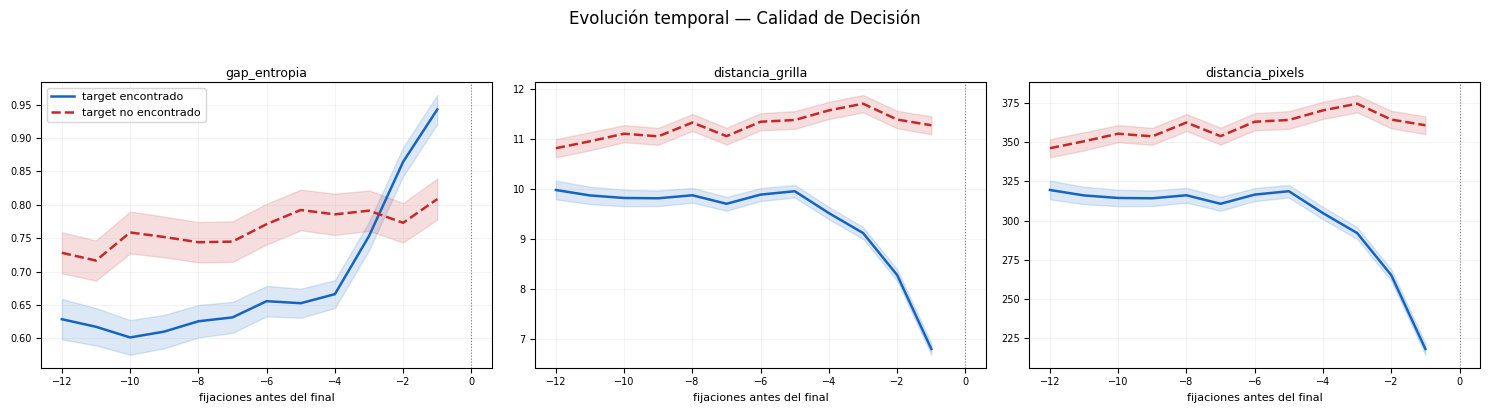

Guardado: curvas_backward_calidad_de_decisión.png


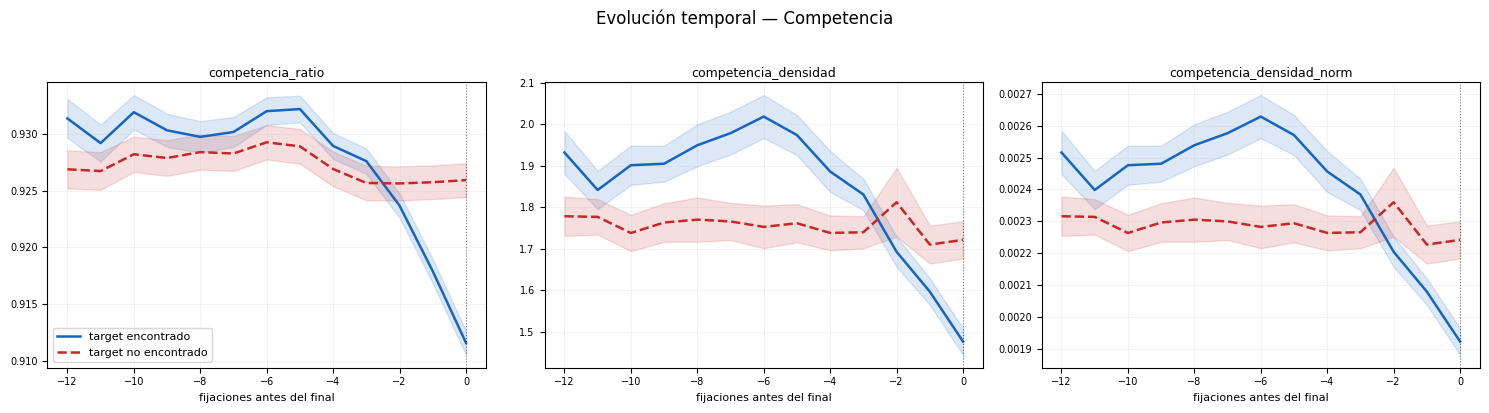

Guardado: curvas_backward_competencia.png


In [62]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Definir features por grupo
GROUPS = {
    'Bottom-Up': [
        'saliencia_media', 'saliencia_mediana', 'saliencia_pixel'
    ],
    'Similitud': [
        'similitud_media', 'similitud_mediana', 'similitud_pixel'
    ],
    'Estado Bayesiano': [
        'evidencia_visual', 'competencia_fp_var', 'competencia_fp_media',
        'competencia_fp_max', 'posterior',
        'entropia_posterior', 'ganancia_informacion'
    ],
    'Calidad de Decisión': [
        'gap_entropia', 'distancia_grilla', 'distancia_pixels'
    ],
    'Competencia': [
        'competencia_ratio', 'competencia_densidad', 'competencia_densidad_norm'
    ],
}

# Layout por grupo: (n_rows, n_cols)
LAYOUT = {
    'Bottom-Up':          (1, 3),
    'Similitud':          (1, 3),
    'Estado Bayesiano':   (2, 4),
    'Calidad de Decisión':(1, 3),
    'Competencia':        (1, 3),
}

subset_bwd = df[df['rank_from_end'] >= -MAX_BWD]

for group_name, feats in GROUPS.items():
    n_rows, n_cols = LAYOUT[group_name]
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             sharey=False)
    axes = np.array(axes).flatten()

    for ax, feat in zip(axes, feats):
        for found in [True, False]:
            grp     = subset_bwd[subset_bwd['target_found'] == found]
            by_rank = grp.groupby('rank_from_end')[feat]
            means   = by_rank.mean()
            sems    = by_rank.sem()
            x       = means.index
            ls      = '-' if found else '--'
            ax.plot(x, means, color=color_map[found],
                    label=label_map[found], lw=1.8, ls=ls)
            ax.fill_between(x, means - sems, means + sems,
                            color=color_map[found], alpha=0.15)

        ax.set_title(feat, fontsize=9, pad=4)
        ax.set_xlabel('fijaciones antes del final', fontsize=8)
        ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.5)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25, lw=0.4)
        ax.set_facecolor('white')

    # Ocultar paneles vacíos (solo aplica a Estado Bayesiano si hay resto)
    for j in range(len(feats), len(axes)):
        axes[j].set_visible(False)

    axes[0].legend(fontsize=8, loc='best')

    fig.patch.set_facecolor('white')
    fig.suptitle(f'Evolución temporal — {group_name}', fontsize=12, y=1.02)
    plt.tight_layout()

    fname = f'curvas_backward_{group_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Guardado: {fname}')

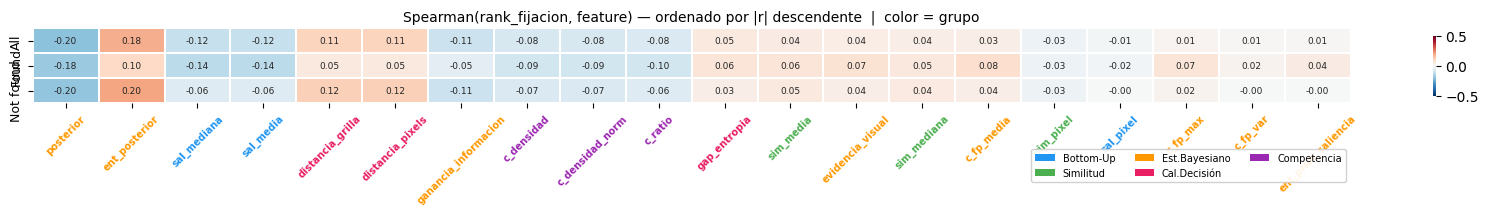

In [63]:
# Spearman global (datos pooleados) — heatmap 3 filas: All / Found / Not Found
heatmap_rows = {}
for label, mask in [('All',       slice(None)),
                    ('Found',     df['target_found'] == True),
                    ('Not found', df['target_found'] == False)]:
    subset = df if label == 'All' else df[mask]
    corrs = {}
    for feat in ALL_FEATS:
        vals = subset[['fixation', feat]].dropna()
        corrs[feat] = round(spearmanr(vals['fixation'], vals[feat]).statistic, 3) if len(vals) > 30 else np.nan
    heatmap_rows[label] = corrs

hm_df = pd.DataFrame(heatmap_rows).T
col_order = hm_df.loc['All'].abs().sort_values(ascending=False).index
hm_df = hm_df[col_order]

SHORT = lambda f: (f.replace('competencia_', 'c_').replace('entropia_', 'ent_')
                    .replace('saliencia_', 'sal_').replace('similitud_', 'sim_'))

fig, ax = plt.subplots(figsize=(17, 2.8))
sns.heatmap(hm_df, ax=ax, cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 6.5}, linewidths=0.3,
            xticklabels=[SHORT(f) for f in col_order],
            cbar_kws={'shrink': 0.8})

for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])
    tick.set_fontweight('bold')
    tick.set_fontsize(7)

ax.set_title('Spearman(rank_fijacion, feature) — ordenado por |r| descendente  |  color = grupo',
             fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=9)

legend_group = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_group, loc='upper right', fontsize=7,
          bbox_to_anchor=(1.0, -0.55), ncol=3, framealpha=0.9)

plt.tight_layout()
plt.savefig('bloque3_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

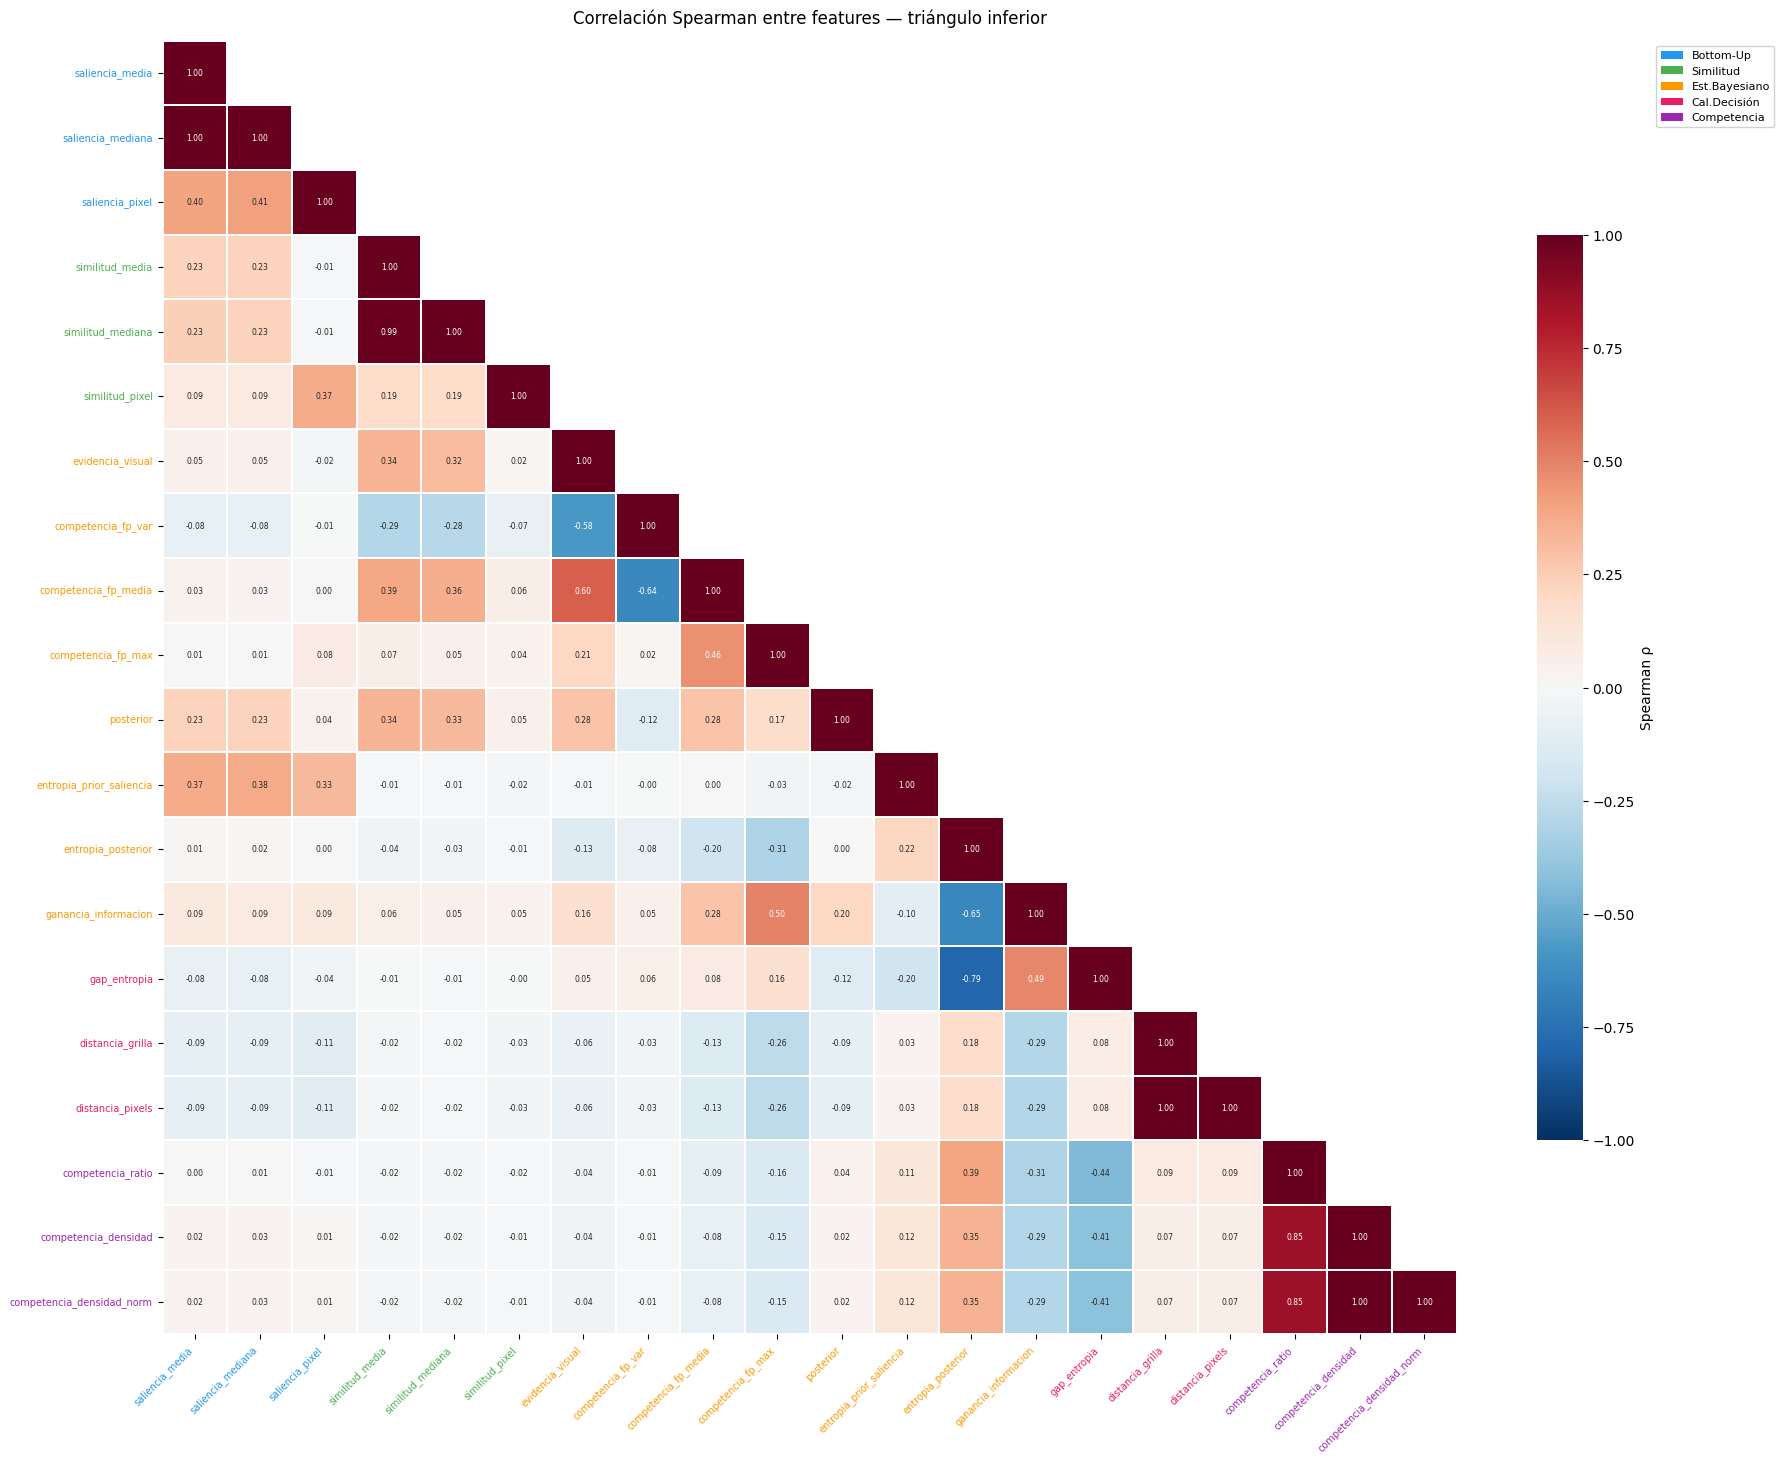

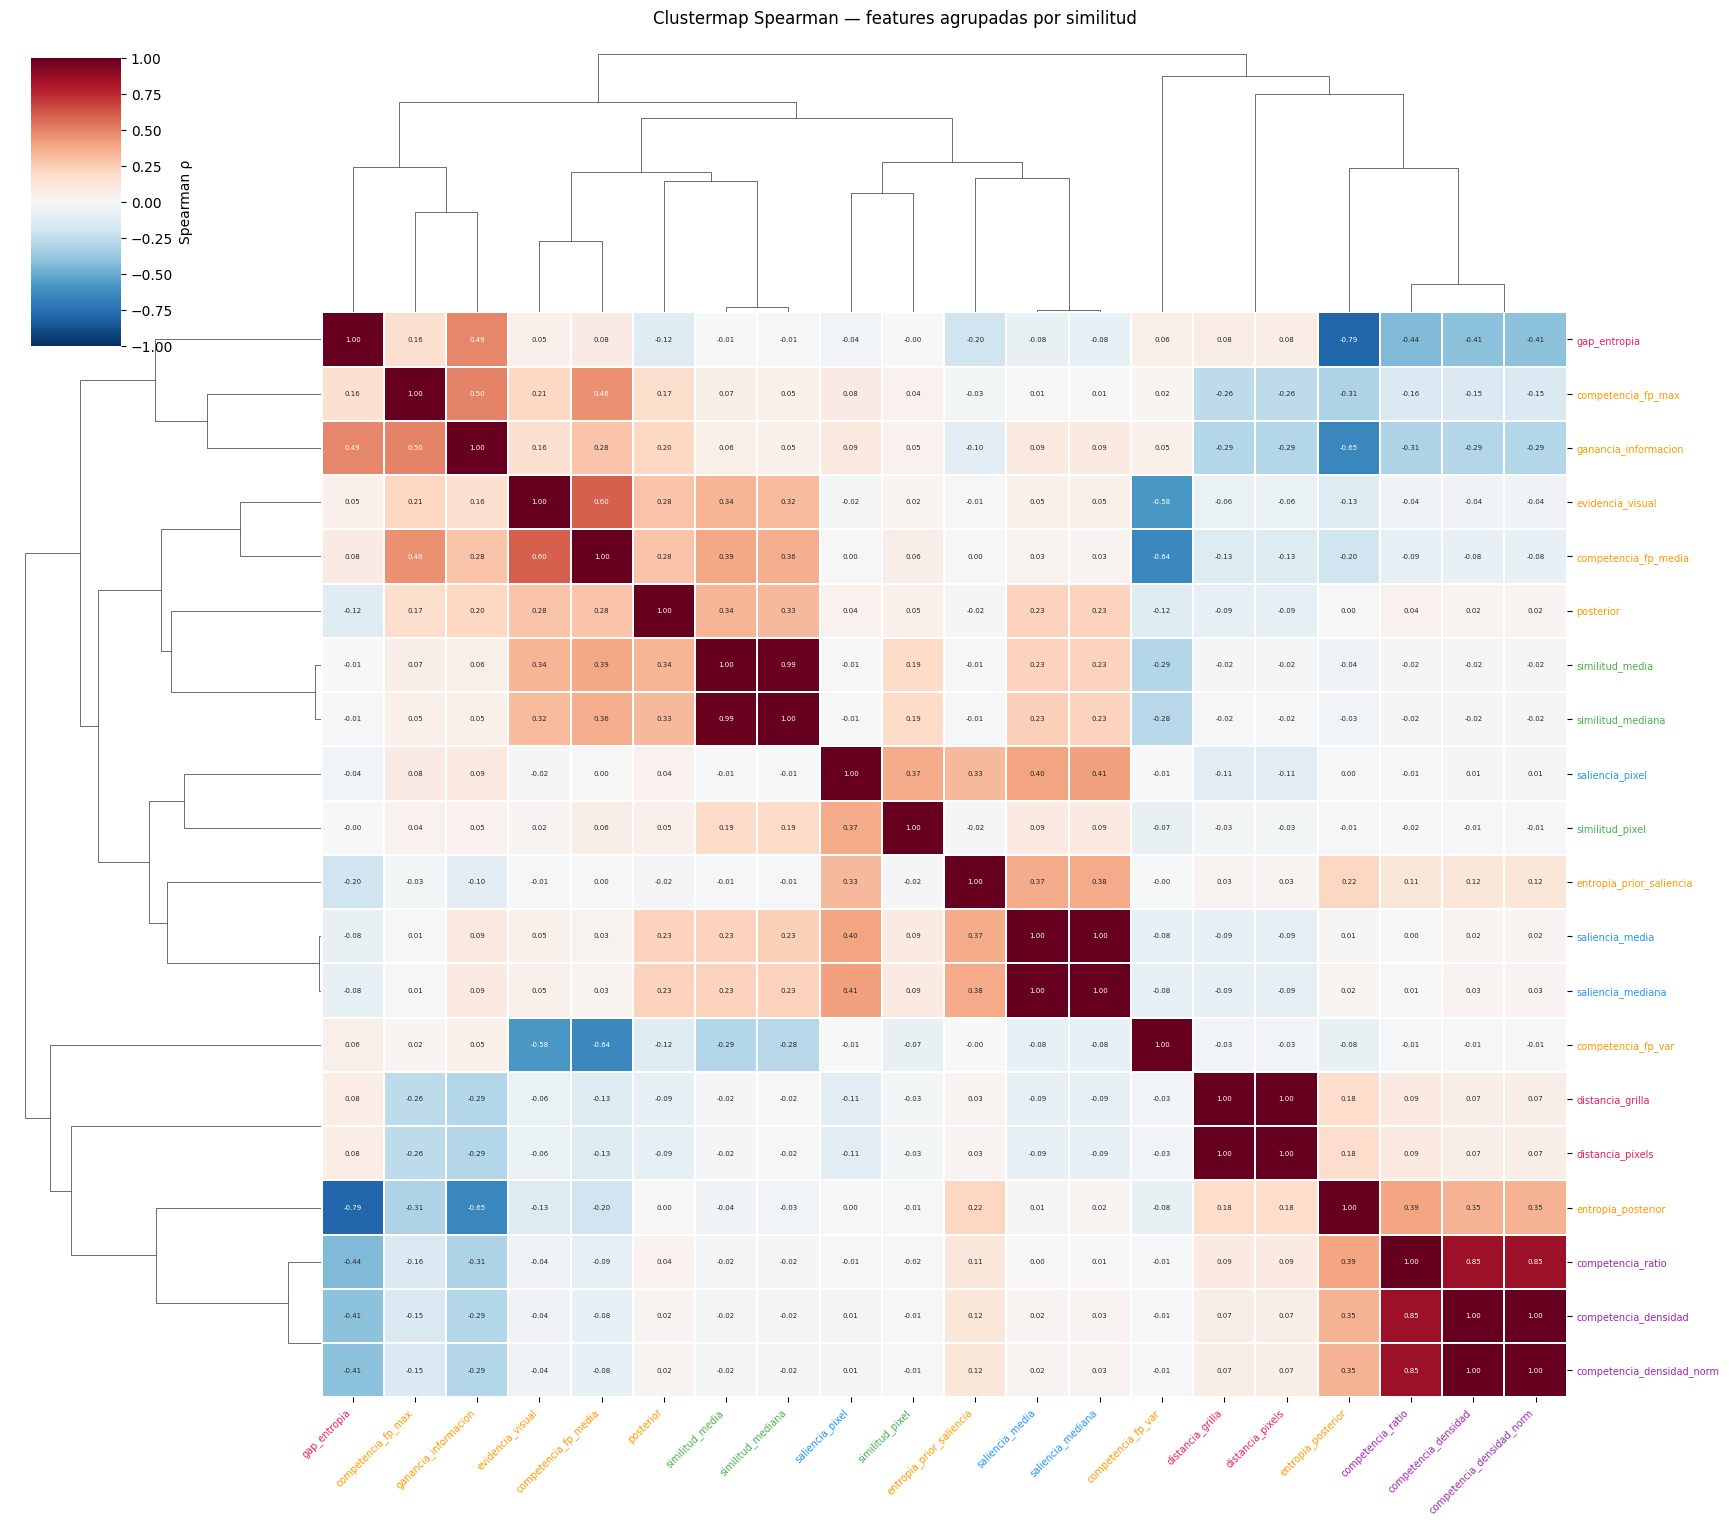

In [65]:
# ── Matriz de correlación Spearman ──────────────────────────────────────────
feats_ok = [f for f in ALL_FEATS if f in df.columns]
corr = df[feats_ok].corr(method='spearman')

# ── Plot 1: heatmap completo ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 5.5},
    linewidths=0.3, square=True,
    xticklabels=feats_ok,
    yticklabels=feats_ok,
    cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'},
)

# Colorear ticks por grupo
group_order = [FEAT_TO_GROUP[f] for f in feats_ok]
for tick, grp in zip(ax.get_xticklabels(), group_order):
    tick.set_color(GROUP_COLORS[grp])
    tick.set_fontsize(7)
    tick.set_rotation(45)
    tick.set_ha('right')
for tick, grp in zip(ax.get_yticklabels(), group_order):
    tick.set_color(GROUP_COLORS[grp])
    tick.set_fontsize(7)
    tick.set_rotation(0)

legend_handles = [mpatches.Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8,
        bbox_to_anchor=(1.25, 1.0), framealpha=0.9)

plt.title('Correlación Spearman entre features — triángulo inferior', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('bloque5_corr_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

# ── Plot 2: clustermap ───────────────────────────────────────────────────────
g = sns.clustermap(
    corr,
    method='average', metric='euclidean',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 5},
    figsize=(18, 16), linewidths=0.3,
    xticklabels=feats_ok,
    yticklabels=feats_ok,
    cbar_kws={'label': 'Spearman ρ'},
)

reordered = [feats_ok[i] for i in g.dendrogram_row.reordered_ind]
for tick, feat in zip(g.ax_heatmap.get_xticklabels(), reordered):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])
    tick.set_fontsize(7)
    tick.set_rotation(45)
    tick.set_ha('right')
for tick, feat in zip(g.ax_heatmap.get_yticklabels(), reordered):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])
    tick.set_fontsize(7)
    tick.set_rotation(0)

g.fig.suptitle('Clustermap Spearman — features agrupadas por similitud',
               fontsize=12, y=1.01)
g.savefig('bloque5_corr_clustermap.png', dpi=150, bbox_inches='tight',
          facecolor='white')
plt.show()

## BLOQUE 6 — Variabilidad intra-sujeto

**Objetivo**: verificar que cada feature presenta variabilidad suficiente *dentro* de cada participante.

El modelo TRF se estima de forma independiente por sujeto: la matriz de diseño de cada participante contiene únicamente sus propias fijaciones. Por lo tanto, una feature que es constante (o casi constante) para un sujeto no contribuirá a explicar su señal cerebral y puede desestabilizar la regresión.

**Métricas usadas**:
| Métrica | Qué mide |
|---------|----------|
| **Std intra-sujeto** | Dispersión absoluta por (sujeto, feature) |
| **CV intra-sujeto** (std / \|mean\|) | Dispersión relativa — comparable entre features de distinta escala |
| **Ratio within/total** | Qué fracción de la varianza total es intra-sujeto |
| **% sujetos con std ≈ 0** | Cuántos participantes tienen la feature casi constante |
| **Punto-masa intra-sujeto** | % del valor más frecuente por sujeto (relevante para features discretizadas) |

In [36]:
# ── Métricas de variabilidad intra-sujeto ───────────────────────────────────
feats_ok = [f for f in ALL_FEATS if f in df.columns]

within_std  = df.groupby('sujeto')[feats_ok].std()
within_mean = df.groupby('sujeto')[feats_ok].mean().abs()
within_cv   = within_std / within_mean.replace(0, np.nan)

total_std   = df[feats_ok].std()
ratio_within = within_std.mean() / total_std

THRESH_STD = 1e-3
pct_low_var = (within_std < THRESH_STD).mean() * 100

summary_within = pd.DataFrame({
    'within_std_median': within_std.median(),
    'within_cv_median':  within_cv.median(),
    'group': [FEAT_TO_GROUP[f] for f in feats_ok],
}).sort_values('within_cv_median', ascending=True)

display(
    summary_within.style
    .format({
        'within_std_median': '{:.4f}',
        'within_cv_median':  '{:.3f}',
    })
)

,within_std_median,within_cv_median,group
competencia_ratio,0.0558,0.060,Competencia
entropia_prior_saliencia,0.4461,0.082,Est.Bayesiano
entropia_posterior,1.6322,0.304,Est.Bayesiano
competencia_fp_var,1.5731,0.342,Est.Bayesiano
competencia_fp_media,0.0811,0.416,Est.Bayesiano
distancia_pixels,191.3993,0.603,Cal.Decisión
distancia_grilla,5.9812,0.603,Cal.Decisión
evidencia_visual,2.2432,0.647,Est.Bayesiano
competencia_densidad,1.4914,0.822,Competencia
competencia_densidad_norm,0.0019,0.822,Competencia


In [38]:
print(within_mean.median())

saliencia_media                0.105515
saliencia_mediana              0.101714
saliencia_pixel                0.044997
similitud_media                0.089745
similitud_mediana              0.082209
similitud_pixel                0.033748
evidencia_visual               3.403971
competencia_fp_var             4.606615
competencia_fp_media           0.196647
competencia_fp_max             4.625101
posterior                      0.013549
entropia_prior_saliencia       5.450193
entropia_posterior             5.393740
ganancia_informacion           0.215230
gap_entropia                   0.674062
distancia_grilla               9.972968
distancia_pixels             319.134971
competencia_ratio              0.926658
competencia_densidad           1.775202
competencia_densidad_norm      0.002311
dtype: float64


In [ ]:
# ── Heatmap: CV intra-sujeto  (sujeto × feature) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={'width_ratios': [2, 1]})

# — Panel izquierdo: CV intra-sujeto —
cv_plot = within_cv[feats_ok].copy()
cv_plot.columns = [SHORT(f) for f in feats_ok]
cv_clipped = cv_plot.clip(upper=5)   # recortar outliers visuales

sns.heatmap(
    cv_clipped, ax=axes[0],
    cmap='YlOrRd', vmin=0, vmax=3,
    linewidths=0.2, linecolor='white',
    cbar_kws={'label': 'CV intra-sujeto (recortado a 5)', 'shrink': 0.8},
    xticklabels=True, yticklabels=True,
)
axes[0].set_title('CV intra-sujeto  (std / |mean|)  —  amarillo = baja variabilidad',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=55, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

for tick, feat in zip(axes[0].get_xticklabels(), feats_ok):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])
    tick.set_fontweight('bold')

# — Panel derecho: % sujetos con std < umbral por feature —
ax2 = axes[1]
colors_bar = [GROUP_COLORS[FEAT_TO_GROUP[f]] for f in feats_ok]
short_labels = [SHORT(f) for f in feats_ok]

ax2.barh(short_labels[::-1], pct_low_var[feats_ok].values[::-1],
         color=colors_bar[::-1], edgecolor='white', linewidth=0.4)
ax2.axvline(20, color='red', lw=1.2, ls='--', alpha=0.7, label='umbral 20%')
ax2.set_xlabel('% sujetos con std < 1e-3', fontsize=9)
ax2.set_title('Sujetos con variabilidad casi nula', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelsize=7)
ax2.legend(fontsize=8)

for tick, feat in zip(ax2.get_yticklabels(), feats_ok[::-1]):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])

plt.tight_layout()
plt.savefig('bloque6_within_subject_cv.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Punto-masa intra-sujeto ──────────────────────────────────────────────────
# Para features potencialmente discretizadas, qué % del valor más frecuente
# tiene cada sujeto → detecta features "pegadas" en un valor dentro del trial

def within_mode_pct(s):
    vc = s.value_counts(normalize=True)
    return vc.iloc[0] * 100 if len(vc) > 0 else np.nan

mode_pct_within = df.groupby('sujeto')[feats_ok].apply(
    lambda grp: grp.apply(within_mode_pct)
)

# Resumen: mediana del % punto-masa por feature
mode_summary = mode_pct_within.median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = [GROUP_COLORS[FEAT_TO_GROUP[f]] for f in mode_summary.index]
ax.bar(range(len(mode_summary)), mode_summary.values, color=colors_bar,
       edgecolor='white', linewidth=0.4)
ax.axhline(30, color='red', lw=1.2, ls='--', alpha=0.7, label='umbral punto-masa 30%')
ax.set_xticks(range(len(mode_summary)))
ax.set_xticklabels([SHORT(f) for f in mode_summary.index], rotation=55,
                   ha='right', fontsize=8)
ax.set_ylabel('Mediana % punto-masa intra-sujeto', fontsize=9)
ax.set_title('Concentración en el valor más frecuente por sujeto\n'
             '(alto → feature casi constante dentro del participante)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

for tick, feat in zip(ax.get_xticklabels(), mode_summary.index):
    tick.set_color(GROUP_COLORS[FEAT_TO_GROUP[feat]])
    tick.set_fontweight('bold')

legend_handles = [mpatches.Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('bloque6_within_subject_pointmass.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen final
print("\nFeatures con mediana punto-masa > 30% (candidatas a revisión):")
print(mode_summary[mode_summary > 30].to_string())